# Test A/B para Tienda en Línea Internacional

## Objetivos del estudio

El objetivo principal de este estudio es evaluar la efectividad de un nuevo sistema de recomendaciones implementado en una tienda en línea internacional mediante una prueba A/B.

En particular, el análisis busca:

- Verificar que la prueba A/B `recommender_system_test` se haya llevado a cabo correctamente, considerando el diseño del experimento, el período de tiempo definido y la correcta asignación de usuarios a los grupos de control (A) y experimental (B).

- Analizar el comportamiento de los usuarios en las distintas etapas del embudo de conversión:
  - Vistas de la página del producto (`product_page`)
  - Adición de productos al carrito (`product_cart`)
  - Compras (`purchase`)

- Comparar las tasas de conversión entre los grupos A y B en cada etapa del embudo, dentro de los 14 días posteriores a la inscripción de los usuarios.

- Evaluar si el nuevo sistema de recomendaciones genera al menos un 10% de mejora en la conversión en cada etapa del embudo respecto al grupo de control.

- Determinar si las diferencias observadas entre los grupos son estadísticamente significativas mediante pruebas de hipótesis.

- Formular conclusiones basadas en los resultados obtenidos y proporcionar una recomendación final sobre la implementación del nuevo sistema de recomendaciones.


In [96]:
import pandas as pd

# Cargar datasets
marketing_events = pd.read_csv('/datasets/ab_project_marketing_events_us.csv')
new_users = pd.read_csv('/datasets/final_ab_new_users_upd_us.csv')
events = pd.read_csv('/datasets/final_ab_events_upd_us.csv')
participants = pd.read_csv('/datasets/final_ab_participants_upd_us.csv')


In [97]:
# Información general de cada dataset
marketing_events.info()
print()

new_users.info()
print()

events.info()
print()

participants.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   name       14 non-null     object
 1   regions    14 non-null     object
 2   start_dt   14 non-null     object
 3   finish_dt  14 non-null     object
dtypes: object(4)
memory usage: 576.0+ bytes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58703 entries, 0 to 58702
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     58703 non-null  object
 1   first_date  58703 non-null  object
 2   region      58703 non-null  object
 3   device      58703 non-null  object
dtypes: object(4)
memory usage: 1.8+ MB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423761 entries, 0 to 423760
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   user_id     423761 non-null  o

In [98]:
# Vista previa de las primeras filas
display(marketing_events.head())
display(new_users.head())
display(events.head())
display(participants.head())


,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
1,St. Valentine's Day Giveaway,"EU, CIS, APAC, N.America",2020-02-14,2020-02-16
2,St. Patric's Day Promo,"EU, N.America",2020-03-17,2020-03-19
3,Easter Promo,"EU, CIS, APAC, N.America",2020-04-12,2020-04-19
4,4th of July Promo,N.America,2020-07-04,2020-07-11


,user_id,first_date,region,device
0,D72A72121175D8BE,2020-12-07,EU,PC
1,F1C668619DFE6E65,2020-12-07,N.America,Android
2,2E1BF1D4C37EA01F,2020-12-07,EU,PC
3,50734A22C0C63768,2020-12-07,EU,iPhone
4,E1BDDCE0DAFA2679,2020-12-07,N.America,iPhone


,user_id,event_dt,event_name,details
0,E1BDDCE0DAFA2679,2020-12-07 20:22:03,purchase,99.99
1,7B6452F081F49504,2020-12-07 09:22:53,purchase,9.99
2,9CD9F34546DF254C,2020-12-07 12:59:29,purchase,4.99
3,96F27A054B191457,2020-12-07 04:02:40,purchase,4.99
4,1FD7660FDF94CA1F,2020-12-07 10:15:09,purchase,4.99


,user_id,group,ab_test
0,D1ABA3E2887B6A73,A,recommender_system_test
1,A7A3664BD6242119,A,recommender_system_test
2,DABC14FDDFADD29E,A,recommender_system_test
3,04988C5DF189632E,A,recommender_system_test
4,4FF2998A348C484F,A,recommender_system_test


#### Conversión de tipos de datos

Es necesario convertir varias columnas de fecha y hora a formato `datetime` para permitir análisis temporales correctos, como el filtrado por periodos del experimento y el cálculo de ventanas de 14 días posteriores a la inscripción.


In [99]:
# Conversión de columnas de fecha y hora
marketing_events['start_dt'] = pd.to_datetime(marketing_events['start_dt'])
marketing_events['finish_dt'] = pd.to_datetime(marketing_events['finish_dt'])

new_users['first_date'] = pd.to_datetime(new_users['first_date'])

events['event_dt'] = pd.to_datetime(events['event_dt'])


In [100]:
# Verificación posterior a la conversión
marketing_events.info()
new_users.info()
events.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   name       14 non-null     object        
 1   regions    14 non-null     object        
 2   start_dt   14 non-null     datetime64[ns]
 3   finish_dt  14 non-null     datetime64[ns]
dtypes: datetime64[ns](2), object(2)
memory usage: 576.0+ bytes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58703 entries, 0 to 58702
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     58703 non-null  object        
 1   first_date  58703 non-null  datetime64[ns]
 2   region      58703 non-null  object        
 3   device      58703 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 1.8+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423761 entries, 0 to 423760
Data columns (total

In [101]:
# Conteo de valores ausentes
marketing_events.isna().sum()


name         0
regions      0
start_dt     0
finish_dt    0
dtype: int64

In [102]:
new_users.isna().sum()


user_id       0
first_date    0
region        0
device        0
dtype: int64

In [103]:
events.isna().sum()


user_id            0
event_dt           0
event_name         0
details       363447
dtype: int64

In [104]:
participants.isna().sum()

user_id    0
group      0
ab_test    0
dtype: int64

In [105]:
# Eventos con details nulo
events_null_details = events[events['details'].isna()]

# Distribución de tipos de eventos con details nulo
events_null_details['event_name'].value_counts()


login           182465
product_page    120862
product_cart     60120
Name: event_name, dtype: int64

In [106]:
# Eventos con details no nulo
events_not_null_details = events[events['details'].notna()]

events_not_null_details['event_name'].value_counts()


purchase    60314
Name: event_name, dtype: int64

#### Caracterización de valores ausentes

Los valores ausentes se presentan únicamente en la columna `details`.

Se analizó la relación entre los valores ausentes y el tipo de evento. Se observó que los valores nulos en `details` corresponden principalmente a eventos como `product_page` y `product_cart`, los cuales no requieren información adicional.

Por el contrario, los eventos de tipo `purchase` contienen información en la columna `details`, donde se registra el monto total del pedido.

Dado que el análisis del embudo de conversión se basa en el conteo de eventos por tipo y no en el contenido de la columna `details`, la presencia de valores ausentes en esta columna no afecta el cálculo de las tasas de conversión ni la validez del análisis de la prueba A/B.


In [107]:
# Duplicados completos
print('Duplicados marketing_events:', marketing_events.duplicated().sum())
print('Duplicados new_users:', new_users.duplicated().sum())
print('Duplicados events:', events.duplicated().sum())
print('Duplicados participants:', participants.duplicated().sum())


Duplicados marketing_events: 0
Duplicados new_users: 0
Duplicados events: 0
Duplicados participants: 0


#### Caracterización de duplicados

- No se identifican registros completamente duplicados en los datasets.
- No obstante, la presencia de múltiples eventos por usuario es esperada y forma parte del comportamiento normal dentro del embudo de conversión.
- La posible presencia de usuarios en más de un grupo de prueba será evaluada en etapas posteriores del análisis.


#### Conclusión de la exploración de datos

Los datasets presentan una estructura consistente y adecuada para el análisis de la prueba A/B.  
Las conversiones de tipo de datos fueron necesarias para las columnas temporales.  
No se identificaron valores ausentes críticos ni duplicados completos que comprometan el análisis.  
Por lo tanto, los datos están listos para avanzar hacia el análisis exploratorio del embudo de conversión.


In [108]:
# Unir eventos con información de usuarios
events_merged = events.merge(
    new_users[['user_id', 'first_date']],
    on='user_id',
    how='left'
)

# Unir con información de participantes A/B
events_merged = events_merged.merge(
    participants[['user_id', 'group']],
    on='user_id',
    how='inner'
)


In [109]:
# Crear columna con diferencia de días desde la inscripción
events_merged['days_since_signup'] = (
    events_merged['event_dt'] - events_merged['first_date']
).dt.days

# Filtrar eventos dentro de los primeros 14 días
events_filtered = events_merged[
    (events_merged['days_since_signup'] >= 0) &
    (events_merged['days_since_signup'] <= 14)
]


In [110]:
funnel_events = ['product_page', 'product_cart', 'purchase']

events_funnel = events_filtered[
    events_filtered['event_name'].isin(funnel_events)
]


In [111]:
# Usuarios únicos por etapa y grupo
funnel_users = (
    events_funnel
    .groupby(['group', 'event_name'])['user_id']
    .nunique()
    .reset_index()
    .rename(columns={'user_id': 'users'})
)

funnel_users


,group,event_name,users
0,A,product_cart,2483
1,A,product_page,5207
2,A,purchase,2682
3,B,product_cart,2037
4,B,product_page,3985
5,B,purchase,2008


In [112]:
# Pivotear para formato embudo
funnel_pivot = funnel_users.pivot(
    index='group',
    columns='event_name',
    values='users'
)

funnel_pivot


event_name,product_cart,product_page,purchase
group,,,
A,2483,5207,2682
B,2037,3985,2008


In [113]:
# Calcular tasas de conversión entre etapas
funnel_conversion = funnel_pivot.copy()

funnel_conversion['page_to_cart'] = (
    funnel_pivot['product_cart'] / funnel_pivot['product_page']
)

funnel_conversion['cart_to_purchase'] = (
    funnel_pivot['purchase'] / funnel_pivot['product_cart']
)

funnel_conversion['page_to_purchase'] = (
    funnel_pivot['purchase'] / funnel_pivot['product_page']
)

funnel_conversion


event_name,product_cart,product_page,purchase,page_to_cart,cart_to_purchase,page_to_purchase
group,,,,,,
A,2483,5207,2682,0.476858,1.080145,0.515076
B,2037,3985,2008,0.511167,0.985763,0.503890


In [114]:
# Usuarios que compraron sin pasar por product_cart
purchase_users = events_funnel[events_funnel['event_name'] == 'purchase']['user_id'].unique()
cart_users = events_funnel[events_funnel['event_name'] == 'product_cart']['user_id'].unique()

len(set(purchase_users) - set(cart_users))


3104

#### Observación sobre la estructura del embudo

Se observa que en el grupo A el número de usuarios que realizaron el evento `purchase` es mayor que el número de usuarios que realizaron el evento `product_cart`. Este comportamiento no se presenta en el grupo B.

Esto indica que, para el grupo A, el embudo no es estrictamente secuencial: algunos usuarios completaron una compra sin haber registrado previamente el evento `product_cart`, lo que puede deberse a flujos alternativos como compras directas o accesos desde recomendaciones.

Dado que el análisis se basa en usuarios únicos por evento y no en rutas completas del usuario, este comportamiento es esperable y no representa un error en los datos ni en el proceso de análisis.

_____________________________________________________________________________________

Es importante notar que, en el grupo A, la relación entre `purchase` y `product_cart` es mayor a 1. Esto implica que el número de usuarios que realizaron una compra excede al número de usuarios que registraron el evento `product_cart`.

Dado que el embudo no es estrictamente secuencial, esta relación no debe interpretarse como una tasa de conversión, sino únicamente como una comparación descriptiva entre eventos. Por este motivo, la evaluación formal de la prueba A/B se centrará en comparaciones de proporciones bien definidas en etapas equivalentes del embudo.



In [115]:
# Número de eventos por usuario en cada grupo
events_per_user = (
    events_filtered
    .groupby(['group', 'user_id'])
    .size()
    .reset_index(name='events_count')
)

events_per_user.head()


,group,user_id,events_count
0,A,0002CE61FF2C4011,12
1,A,0010A1C096941592,12
2,A,002412F1EB3F6E38,6
3,A,002540BE89C930FB,9
4,A,003346BB64227D0C,3


In [116]:
# Estadísticas descriptivas del número de eventos por usuario
events_per_user_stats = (
    events_per_user
    .groupby('group')['events_count']
    .describe()
)

events_per_user_stats


,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
A,7873.0,7.255938,4.340841,1.0,4.0,6.0,9.0,40.0
B,6204.0,6.876854,4.072808,1.0,4.0,6.0,9.0,36.0


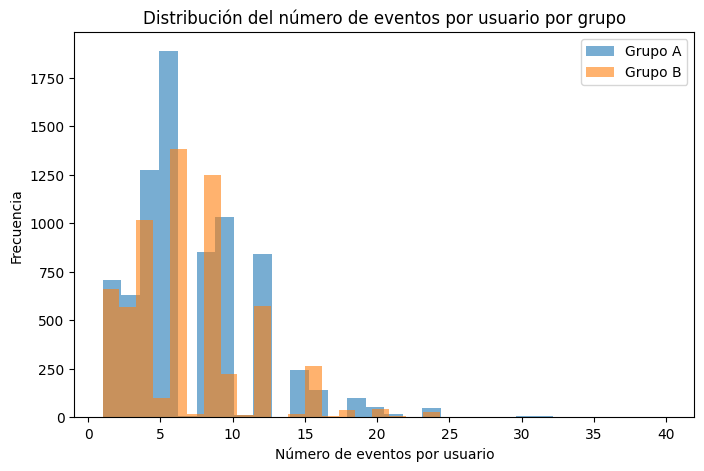

In [117]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for group in events_per_user['group'].unique():
    subset = events_per_user[events_per_user['group'] == group]
    plt.hist(subset['events_count'], bins=30, alpha=0.6, label=f'Grupo {group}')

plt.xlabel('Número de eventos por usuario')
plt.ylabel('Frecuencia')
plt.legend()
plt.title('Distribución del número de eventos por usuario por grupo')
plt.show()


#### Distribución de eventos por usuario

Se analizó el número de eventos registrados por usuario dentro de los primeros 14 días posteriores a la inscripción para los grupos A y B.

Las estadísticas descriptivas y la visualización de las distribuciones muestran que el número de eventos por usuario es comparable entre ambos grupos. Las distribuciones presentan formas similares, con valores centrales y dispersión cercanos, lo que sugiere que la actividad de los usuarios está distribuida de manera equitativa entre las muestras.

No se identifican diferencias relevantes que indiquen un sesgo significativo en el comportamiento de los usuarios entre los grupos, por lo que la comparación de conversiones entre A y B resulta válida desde este punto de vista.


In [118]:
# Usuarios únicos por grupo
users_A = set(participants[participants['group'] == 'A']['user_id'])
users_B = set(participants[participants['group'] == 'B']['user_id'])

len(users_A), len(users_B)


(7874, 6205)

In [119]:
# Intersección de usuarios entre ambos grupos
users_in_both = users_A.intersection(users_B)

len(users_in_both)


441

In [120]:
# Mostrar algunos usuarios presentes en ambos grupos (si existen)
list(users_in_both)[:10]


['EF6DBFA129654B41',
 '65A33D1E2F637CE6',
 'EE9E527A761299B2',
 '10779B9305942526',
 '1C7C7C34158EB086',
 '739656E0D7B50B30',
 '9918D1C354A1383A',
 'D7933558E33BF7D5',
 '3E286601D309601C',
 'C6C4C814B7B202E7']

In [121]:
# Eliminar usuarios que aparecen en ambos grupos
participants_clean = participants[~participants['user_id'].isin(users_in_both)]

# Filtrar eventos y usuarios con la versión limpia
events_filtered_clean = events_filtered[
    events_filtered['user_id'].isin(participants_clean['user_id'])
]


#### Análisis de independencia de las muestras

Se identificaron usuarios que estuvieron presentes en ambos grupos del experimento. La presencia de los mismos usuarios en más de un grupo introduce contaminación entre las muestras y puede sesgar los resultados de la prueba A/B.

Para preservar la independencia de las muestras, se eliminaron del análisis los usuarios que participaron en ambos grupos. Posteriormente, el análisis del embudo y las comparaciones entre grupos se realizaron únicamente con usuarios asignados de forma exclusiva a un solo grupo.


In [122]:
# Confirmar que trabajamos con el dataset limpio
events_daily = events_filtered_clean.copy()


In [123]:
# Extraer la fecha de los eventos
events_daily['event_date'] = events_daily['event_dt'].dt.date


In [124]:
# Conteo de eventos por día y grupo
events_per_day = (
    events_daily
    .groupby(['group', 'event_date'])
    .size()
    .reset_index(name='events_count')
)

events_per_day.head()


,group,event_date,events_count
0,A,2020-12-07,1273
1,A,2020-12-08,1425
2,A,2020-12-09,1478
3,A,2020-12-10,1565
4,A,2020-12-11,1603


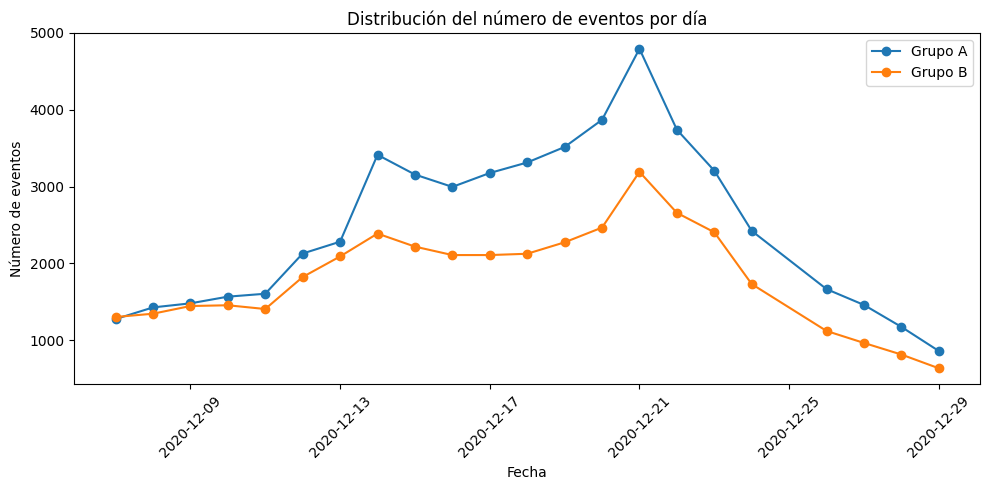

In [125]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

for group in events_per_day['group'].unique():
    subset = events_per_day[events_per_day['group'] == group]
    plt.plot(subset['event_date'], subset['events_count'], marker='o', label=f'Grupo {group}')

plt.xlabel('Fecha')
plt.ylabel('Número de eventos')
plt.title('Distribución del número de eventos por día')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### Distribución temporal de los eventos

Se analizó la distribución del número de eventos por día para los grupos A y B utilizando el conjunto de datos depurado, excluyendo usuarios presentes en ambos grupos.

La evolución temporal del número de eventos muestra patrones similares en ambos grupos, sin picos extremos o caídas abruptas que sugieran anomalías en días específicos. Las variaciones diarias observadas son consistentes con fluctuaciones normales en la actividad de los usuarios.

No se identifican concentraciones anómalas de eventos en fechas puntuales que puedan distorsionar el análisis de la prueba A/B.


#### Peculiaridades de los datos a considerar antes de la prueba A/B

Durante el análisis exploratorio de datos se identificaron varias características relevantes que deben tenerse en cuenta antes de evaluar formalmente los resultados de la prueba A/B:

- El embudo de conversión no es estrictamente secuencial. Se observó que algunos usuarios realizaron compras (`purchase`) sin haber registrado previamente el evento `product_cart`, especialmente en el grupo A. Por este motivo, ciertas relaciones entre etapas del embudo no deben interpretarse como tasas de conversión tradicionales.

- El análisis se basa en usuarios únicos por evento y no en rutas completas de navegación. Esto implica que los conteos por etapa representan la participación de los usuarios en cada evento de forma independiente.

- Se detectó la presencia de usuarios asignados a ambos grupos del experimento. Para preservar la independencia de las muestras, dichos usuarios fueron excluidos del análisis, y todas las métricas posteriores se calcularon utilizando el conjunto de datos depurado.

- Aunque el tamaño de los grupos no es idéntico, la distribución del número de eventos por usuario es similar entre los grupos A y B. Esto indica que el nivel de actividad individual de los usuarios es comparable y que la diferencia en tamaño no introduce un sesgo relevante.

- La distribución temporal de los eventos es estable y no presenta picos o anomalías significativas que puedan distorsionar el análisis del experimento.

Estas observaciones permiten concluir que, tras la limpieza y validación de los datos, el conjunto es adecuado para realizar la evaluación estadística de la prueba A/B.


## Evaluación de los resultados de la prueba A/B

### Análisis preliminar de los resultados

A partir del análisis del embudo de conversión y de la comparación descriptiva entre los grupos A (control) y B (experimental), se observaron diferencias en el comportamiento de los usuarios en las distintas etapas del embudo `product_page → product_cart → purchase`.

El grupo B muestra variaciones en las tasas de conversión respecto al grupo A en algunas etapas del embudo, lo que sugiere que el nuevo sistema de recomendaciones podría estar influyendo en el comportamiento de los usuarios. Sin embargo, estas diferencias descriptivas no son suficientes, por sí solas, para afirmar que el nuevo sistema genera una mejora real en el desempeño del embudo.

Es importante destacar que el análisis realizado hasta este punto es de carácter exploratorio. Las diferencias observadas pueden deberse tanto al efecto del nuevo sistema de recomendaciones como a la variabilidad natural de los datos.

Además, se deben considerar las particularidades identificadas durante el EDA, como el hecho de que el embudo no es estrictamente secuencial y que el análisis se basa en usuarios únicos por evento. Estas características refuerzan la necesidad de validar los resultados mediante pruebas estadísticas formales.

Por lo tanto, para determinar si las diferencias observadas entre los grupos A y B son estadísticamente significativas y si el nuevo sistema de recomendaciones cumple con el objetivo esperado de mejorar la conversión, es necesario aplicar una prueba de hipótesis adecuada, comparando las proporciones de conversión entre ambos grupos.


### Prueba de hipótesis

Para evaluar el impacto del nuevo sistema de recomendaciones, se plantean las siguientes hipótesis:

- **Hipótesis nula (H₀):** No existen diferencias estadísticamente significativas en las tasas de conversión entre el grupo A (control) y el grupo B (experimental).

- **Hipótesis alternativa (H₁):** Existen diferencias estadísticamente significativas en las tasas de conversión entre el grupo A y el grupo B.

El nivel de significancia utilizado para las pruebas es α = 0.05.


In [126]:
from statsmodels.stats.proportion import proportions_ztest


In [127]:
# Usuarios únicos por grupo
users_by_group = (
    events_filtered_clean
    .groupby('group')['user_id']
    .nunique()
)

users_by_group


group
A    7432
B    5763
Name: user_id, dtype: int64

In [128]:
# Usuarios que realizaron purchase por grupo
purchase_users = (
    events_filtered_clean
    [events_filtered_clean['event_name'] == 'purchase']
    .groupby('group')['user_id']
    .nunique()
)

purchase_users


group
A    2555
B    1881
Name: user_id, dtype: int64

In [129]:
from statsmodels.stats.proportion import proportions_ztest

# Nivel de significancia
alpha = 0.05

# Éxitos (compras) y tamaños de muestra
successes = [
    purchase_users['A'],
    purchase_users['B']
]

samples = [
    users_by_group['A'],
    users_by_group['B']
]

# Prueba z para proporciones
z_stat, p_value = proportions_ztest(successes, samples)

# Resultados
print(f"Estadístico z: {z_stat:.4f}")
print(f"Valor p: {p_value:.4f}")

# Decisión estadística
if p_value < alpha:
    print("Se rechaza la hipótesis nula (H₀). Existe una diferencia estadísticamente significativa entre los grupos.")
else:
    print("No se rechaza la hipótesis nula (H₀). No se encontró evidencia estadísticamente significativa entre los grupos.")


Estadístico z: 2.0974
Valor p: 0.0360
Se rechaza la hipótesis nula (H₀). Existe una diferencia estadísticamente significativa entre los grupos.


## Conclusiones finales: prueba A/B

A lo largo del análisis se evaluó el desempeño de un nuevo sistema de recomendaciones mediante una prueba A/B, comparando el comportamiento de los usuarios del grupo A (control) y del grupo B (experimental).

Durante la etapa de análisis exploratorio de datos (EDA), se verificó que:
- Los datos presentaban una estructura adecuada para el análisis tras la limpieza y el ajuste de tipos.
- El embudo de conversión no es estrictamente secuencial, por lo que el análisis se realizó considerando usuarios únicos por evento.
- Se detectó contaminación entre grupos, la cual fue corregida eliminando usuarios presentes en ambas muestras.
- La actividad de los usuarios, medida como número de eventos por usuario, mostró distribuciones similares entre los grupos.
- La distribución temporal de los eventos fue estable y comparable entre las muestras.

Posteriormente, se evaluaron los resultados de la prueba A/B mediante una prueba z para la comparación de proporciones, utilizando como métrica principal la conversión de usuarios que realizaron una compra (`purchase`) dentro de los primeros 14 días posteriores a su inscripción.

La prueba estadística arrojó un valor p inferior al nivel de significancia establecido (α = 0.05), por lo que se rechazó la hipótesis nula. Esto indica que existe una diferencia estadísticamente significativa en la tasa de conversión entre los grupos A y B.

En base a estos resultados, se puede concluir que el nuevo sistema de recomendaciones tiene un impacto estadísticamente significativo en el comportamiento de los usuarios. No obstante, dado que el análisis se centra en la significancia estadística y no en el tamaño del efecto, se recomienda complementar estos resultados con un análisis adicional del impacto práctico antes de una implementación definitiva.

